In [2]:
import os
from SSD_eval.SSD_utils import get_project_root
from pathlib import Path
import sys
from ipywidgets import interact

os.chdir(get_project_root())

ssd_eval_path = str(Path.cwd() / "SSD_eval")
if ssd_eval_path not in sys.path:
    sys.path.insert(0, ssd_eval_path)

from SSD_eval.SSD_test_utils import *

%matplotlib widget

Loading model from checkpoint: checkpoints/training_logs/control/biased_50/checkpoints/last.ckpt
Loaded default weights from checkpoints/training_logs/control/biased_50/checkpoints/last.ckpt
tensor([[ 1.0000,  0.0000,  0.0000,  0.1111, -0.4444, -0.4286,  0.8869, -0.4620,
          1.0000, -0.9922, -0.9922],
        [ 1.0000,  0.0000,  0.0000,  0.6667,  0.0000,  0.7143,  0.9888, -0.1493,
         -0.0039,  0.4196,  0.0980],
        [ 0.0000,  1.0000,  0.0000, -0.3333, -0.8889,  1.0000,  0.3295,  0.9441,
         -0.5451, -0.6314, -0.6392]], device='cuda:0')
tensor([[ 1.4294, -1.7200, -1.6573,  0.2785, -0.1781, -0.4025,  0.7581, -0.3720,
          0.9547, -0.9727, -0.9594],
        [ 1.0706, -0.4010,  0.0992,  0.7623, -0.3205,  0.5889,  0.9092, -0.3762,
         -0.1140,  0.0577, -0.1016],
        [-2.3769, -0.7085,  1.4157, -0.7749, -0.2855,  0.8561,  0.6724,  0.9300,
         -0.7217, -0.4483, -0.4715]], device='cuda:0',
       grad_fn=<SliceBackward0>)


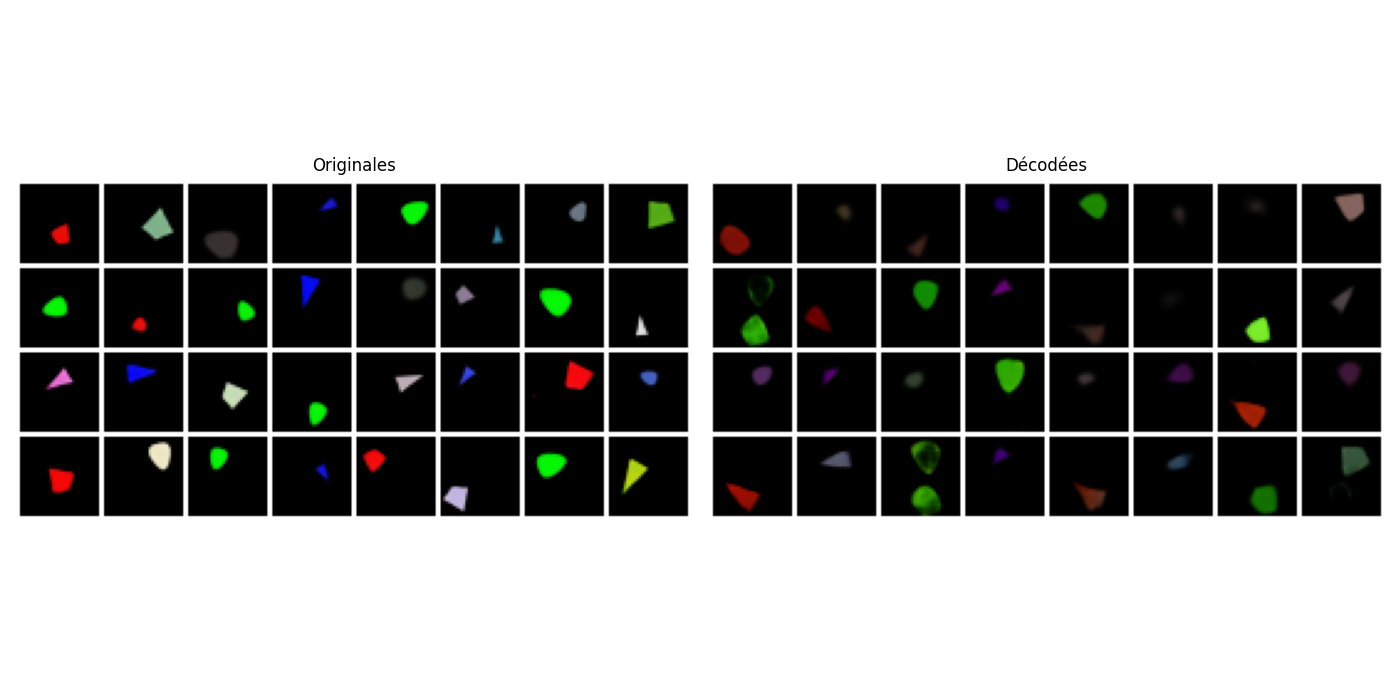

In [ ]:
project_name = "control"
experiment_name = "biased_50"

n_samples = 32
show_results_fusion = True
fusion_attr_weight = 1.0


training_params = get_training_params(project_name, experiment_name)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

global_workspace = get_global_workspace(project_name, experiment_name)
data_module = get_data_module(project_name,  experiment_name)
train_samples = get_data_samples(data_module, n_samples)
data_translated = get_data_translated(global_workspace, train_samples, n_samples, fusion_attr_weight, show_results_fusion)

print(data_translated["train_attr"][0:3])
print(data_translated["attr_decoded"][0:3])
plot_original_translated_comparison(data_translated["train_images"], data_translated["images_decoded"])

In [13]:
training_params["config"]

Config(seed=0, ood_seed=None, default_root_dir=PosixPath('checkpoints'), dataset=Dataset(path='./simple_shapes_dataset_biased_80'), training=Training(batch_size=2056, num_workers=16, devices=1, accelerator='gpu', fast_dev_run=False, max_steps=150000, enable_progress_bar=True, precision=32, float32_matmul_precision='highest', optim=Optim(lr=1e-05, max_lr=0.00015, start_lr=0.0001, end_lr=1e-05, pct_start=0.03, weight_decay=1e-06)), wandb=WanDB(enabled=True, save_dir='./wandb', project='Shimmer-SSD', entity='lexman-psl', reinit=False), logging=Logging(filter_images=['pred_trans_attr_to_attr', 'pred_trans_v_latents_to_v_latents', 'pred_trans_attr_to_v_latents', 'pred_trans_v_latents_to_attr', 'pred_cycle_v_latents_to_attr', 'pred_cycle_attr_to_v_latents', 'pred_cycle_v_latents_to_v_latents', 'pred_cycle_attr_to_attr'], log_train_medias_every_n_epochs=1, log_val_medias_every_n_epochs=1), title=None, desc=None, domain_proportions={frozenset({'attr'}): 1.0, frozenset({'v'}): 1.0, frozenset({'

In [14]:
@interact(
    cat=["Triangle", "Egg", "Diamond"],
    x=(0, 1, 0.1),
    y=(0, 1, 0.1),
    rot=(0, 1, 0.1),
    size=(0, 1, 0.1),
    color_r=(0, 1, 0.1),
    color_g=(0, 1, 0.1),
    color_b=(0, 1, 0.1),
)
def play_with_gw(
    cat: str = "Triangle",
    x: float = 0.5,
    y: float = 0.5,
    rot: float = 0.5,
    size: float = 0.5,
    color_r: float = 1,
    color_g: float = 0,
    color_b: float = 0,
):
    original_image = get_image(cat, x, y, size, rot, color_r, color_g, color_b)
    decoded_image = get_decoded_image(cat, x, y, size, rot, color_r, color_g, color_b, training_params, device, global_workspace)
    plot_interactive(original_image, decoded_image)



interactive(children=(Dropdown(description='cat', options=('Triangle', 'Egg', 'Diamond'), value='Triangle'), F…